In [1]:
import pandas as pd
import numpy as np
import pickle
import os

def get_adjacency_matrix(distance_df, sensor_ids, normalized_k=0.1):
    num_sensors = len(sensor_ids)

    # Asociem fiecărui ID de senzor poziția sa în matrice
    sensor_to_ind = {int(sensor_id): i for i, sensor_id in enumerate(sensor_ids)}

    # Inițializare matrice de adiacență
    adj_mx = np.zeros((num_sensors, num_sensors), dtype=np.float32)

    # Deviația standard este utilizată la calculul ponderilor muchiilor
    distances = distance_df['cost'].values
    distances = distances[distances > 0]
    std_dist = np.std(distances)

    # Construirea matricei de adiacență pe baza distanțelor dintre senzori
    for row in distance_df.itertuples(index=False):
        u_id = int(row[0])
        v_id = int(row[1])
        cost = row[2]

        if u_id in sensor_to_ind and v_id in sensor_to_ind:
            u = sensor_to_ind[u_id]
            v = sensor_to_ind[v_id]

            # Pondere calculată cu funcția Gaussian Kernel
            weight = np.exp(-(cost**2 / std_dist**2))

            # Sunt păstrate doar conexiunile cu pondere suficient de mare
            if weight >= normalized_k:
                adj_mx[u, v] = weight

    return adj_mx


#Încărcarea datelor
print("Încărcare date senzori...")

dist_df = pd.read_csv("distances_bay_2017.csv")
locations_df = pd.read_csv("graph_sensor_locations_bay.csv")

# Ordinea senzorilor trebuie să fie aceeași cu cea utilizată în setul de date PEMS-BAY
sensor_ids = locations_df["sensor_id"].values

print(f"Detectați {len(sensor_ids)} senzori.")

adj_mx = get_adjacency_matrix(dist_df, sensor_ids)

# Crearea folderului pentru rezultate
if not os.path.exists("Rezultate"):
    os.makedirs("Rezultate")

# Salvarea matricei de adiacență în format utilizat de modele
output_path = os.path.join("Rezultate", "adj_mx_bay.pkl")

with open(output_path, "wb") as f:
    pickle.dump([sensor_ids, sensor_ids, adj_mx], f)

print(f"Matricea a fost salvată în: {output_path}")
print(f"Sparsity: {np.count_nonzero(adj_mx) / (adj_mx.shape[0]**2) * 100:.2f}%")

Încărcare date senzori...
Detectați 325 senzori.
Matricea a fost salvată în: Rezultate\adj_mx_bay.pkl
Sparsity: 2.40%


Forma matricei: (325, 325)
Valoare maximă: 1.0
Valoare medie (fără 0): 0.621920108795166


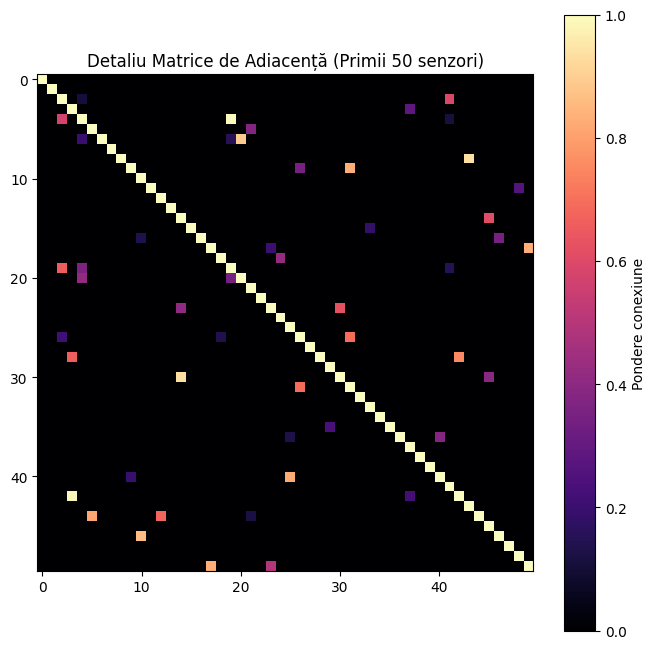

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Încărcarea matricei generate
with open("Rezultate/adj_mx_bay.pkl", 'rb') as f:
    sensor_ids, _, adj_mx = pickle.load(f)

print(f"Forma matricei: {adj_mx.shape}")
print(f"Valoare maximă: {np.max(adj_mx)}") 
print(f"Valoare medie (fără 0): {adj_mx[adj_mx > 0].mean()}")

# Afișarea unui fragment din matrice pentru verificare
plt.figure(figsize=(8, 8))
plt.imshow(adj_mx[:50, :50], cmap='magma')
plt.colorbar(label='Pondere conexiune')
plt.title("Detaliu Matrice de Adiacență (Primii 50 senzori)")
plt.show()